# 1. Import and Hardware Setup

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split, Subset
import os
import random
import matplotlib.pyplot as plt
import numpy as np
!pip install tqdm -q
from tqdm.auto import tqdm
# Set device to GPU, MPS, or CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [21]:
DATA_PATH = './data'

# 2. Hyperparameter

In [22]:
BATCH_SIZE = 256
IMG_SIZE = 128
IN_CHANNELS = 3

LR = 1e-4
EPOCHS = 100
SEED = 42
NUM_CLASSES = 50

ENCODER_CHANNELS = [32, 64, 128, 256, 512]

# Dimensionality of the latent code.
# A larger value gives the model more capacity, but also more
# dimensions to sparsify.
LATENT_DIM = 512

# Weight for the sparsity (L1) penalty on the latent activations.
# A higher value forces more units to be zero, increasing sparsity
# but may reduce reconstruction quality.
SPARSITY_WEIGHT = 1e-4


# 3. Data Preparation

In [23]:
def set_seed(seed: int = 42):
    """Set all random seeds for reproducibility."""
    os.environ['PYTHONHASHSEED'] = str(seed)

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass


def seed_worker(worker_id):
    """Seed function for DataLoader workers to ensure reproducibility."""
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)


In [24]:
train_transform = transforms.Compose(
    [
        transforms.Resize(IMG_SIZE + 32),
        transforms.RandomCrop(IMG_SIZE),
        transforms.RandomRotation(15),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
    ]
)

val_transform = transforms.Compose(
    [
        transforms.Resize(IMG_SIZE + 32),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
    ]
)

# Apply seed
set_seed(SEED)
train_generator = torch.Generator().manual_seed(SEED)
eval_generator = torch.Generator().manual_seed(SEED)

dummy_data = datasets.Food101(root=DATA_PATH, split="train", download=True)

filtered_indices = [i for i, label in enumerate(dummy_data._labels) if label < NUM_CLASSES]

train_size = int(0.8 * len(filtered_indices))
val_size = len(filtered_indices) - train_size
split_generator = torch.Generator().manual_seed(SEED)

filtered_dummy_data = Subset(dummy_data, filtered_indices)
train_tmp_subset, val_tmp_subset = random_split(
    filtered_dummy_data, [train_size, val_size], generator=split_generator
)

train_indices = [filtered_indices[i] for i in train_tmp_subset.indices]
val_indices = [filtered_indices[i] for i in val_tmp_subset.indices]

train_dataset = datasets.Food101(
    root=DATA_PATH,
    split="train",
    download=False,
    transform=train_transform,
)

val_dataset = datasets.Food101(
    root=DATA_PATH,
    split="train",
    download=False,
    transform=val_transform,
)

train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(val_dataset, val_indices)


dummy_test_dataset = datasets.Food101(root=DATA_PATH, split="test", download=True)
test_filterd_indices = [
    i for i, label in enumerate(dummy_test_dataset._labels) if label < NUM_CLASSES
]

test_dataset_full = datasets.Food101(
    root=DATA_PATH,
    split="test",
    download=False,
    transform=val_transform,
)
test_dataset = Subset(test_dataset_full, test_filterd_indices)


In [25]:
train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True,
    num_workers=4,
    persistent_workers=True,
    prefetch_factor=10,
    worker_init_fn=seed_worker,
    generator=train_generator,
)

val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
    num_workers=4,
    persistent_workers=True,
    prefetch_factor=10,
    worker_init_fn=seed_worker,
    generator=eval_generator,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
    num_workers=4,
    persistent_workers=True,
    prefetch_factor=10,
    worker_init_fn=seed_worker,
    generator=eval_generator,
)


# 4. Model Architecture

## SAE Key Differences vs. Standard Autoencoder

1. **Sparse latent code**: The encoder maps the input to a deterministic latent vector `z`
   (like a standard AE), but an L1 sparsity penalty is added to the loss to encourage
   most latent dimensions to be exactly (or near) zero.
2. **ReLU bottleneck**: A ReLU activation after the linear projection naturally truncates
   negative activations to zero, which further promotes sparsity.
3. **Loss = Reconstruction Loss (MSE) + Sparsity Loss (L1)**:
   - Reconstruction Loss: Standard pixel-level MSE between input and output.
   - Sparsity Loss: L1 norm of the latent code, i.e. `||z||_1`.
4. **No probabilistic sampling**: Unlike a VAE, there is no reparameterization trick.
   The encoder output is used directly (deterministic forward pass).
5. **Active-unit analysis**: After training, we measure the fraction of latent dimensions
   that are non-zero on the test set to quantify sparsity.


In [26]:
class ConvBA(nn.Sequential):
    """Convolutional block: Conv2d -> BatchNorm -> LeakyReLU."""

    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size=3,
        stride=2,  # stride-2 to halve spatial dims
        padding=1,
    ):
        super().__init__(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2, inplace=True),
        )


class ConvTransBA(nn.Sequential):
    """Transposed convolutional block: ConvTranspose2d -> BatchNorm -> LeakyReLU."""

    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size=3,
        stride=2,
        padding=1,
        output_padding=1,
    ):
        super().__init__(
            nn.ConvTranspose2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                output_padding=output_padding,
            ),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2, inplace=True),
        )


# ─────────────────── Residual Block ───────────────────────────────────────
class ResidualBlock(nn.Module):
    """
    Residual block with internal skip connection: out = F(x) + x.

    Two 3x3 convolutions at the same spatial resolution.  If in_channels
    differs from out_channels, a learned 1x1 projection aligns the shortcut
    so the addition is always valid.  This lets the network go deeper
    without vanishing gradients while keeping the bottleneck intact.
    """

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels, out_channels, kernel_size=3, padding=1, bias=False,
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(
            out_channels, out_channels, kernel_size=3, padding=1, bias=False,
        )
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.act = nn.LeakyReLU(0.2, inplace=True)

        # Shortcut projection when channel counts differ
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.act(out + identity)


# ─────────────────── Sparse Autoencoder ──────────────────────────────────
class SparseAutoencoder(nn.Module):
    """
    Sparse Autoencoder with Residual Blocks (no U-Net skip connections).

    Compared to the flat version this model adds a ResidualBlock after
    every downsampling (encoder) and upsampling (decoder) stage.  The
    internal skip connection inside each residual block (out = F(x) + x)
    stabilises gradient flow and enables deeper feature extraction, while
    the information bottleneck through the latent code z is preserved.

    Architecture:
        Encoder: [ConvBA (stride-2) -> ResidualBlock] x N -> Flatten -> Linear -> ReLU
        Decoder: Linear -> Unflatten -> [ConvTransBA (stride-2) -> ResidualBlock] x N -> Sigmoid
    """

    def __init__(self, in_channels, img_size, encoder_channels, latent_dim):
        super().__init__()

        num_layers = len(encoder_channels)

        # Spatial resolution after all stride-2 downsamples
        self.final_h = img_size // (2 ** num_layers)
        self.final_w = img_size // (2 ** num_layers)
        assert self.final_h >= 1 and self.final_w >= 1, "Too many downsamplings"

        # ───────────── Encoder ─────────────────────────────────────────
        # Each stage: ConvBA (halves resolution) followed by a ResidualBlock
        # that refines features at that resolution.
        encoder_layers = []
        curr_channels = in_channels

        for out_ch in encoder_channels:
            encoder_layers.append(ConvBA(curr_channels, out_ch))
            encoder_layers.append(ResidualBlock(out_ch, out_ch))
            curr_channels = out_ch

        encoder_layers.append(nn.Flatten())
        self.encoder_conv = nn.Sequential(*encoder_layers)

        # Flattened feature size after all conv layers
        flattened_size = curr_channels * self.final_h * self.final_w

        # SAE-specific: linear projection followed by ReLU to produce
        # non-negative sparse activations.
        self.fc_encode = nn.Linear(flattened_size, latent_dim)
        self.relu = nn.ReLU(inplace=True)  # ensures z >= 0, aids sparsity

        # ───────────── Decoder ─────────────────────────────────────────
        decoder_layers = []
        decoder_layers.extend(
            [
                nn.Linear(latent_dim, flattened_size),
                nn.LeakyReLU(0.2, inplace=True),
                nn.Unflatten(1, (curr_channels, self.final_h, self.final_w)),
            ]
        )

        rev_channels = list(reversed(encoder_channels))
        for i in range(len(rev_channels) - 1):
            in_ch = rev_channels[i]
            out_ch = rev_channels[i + 1]
            decoder_layers.append(ConvTransBA(in_ch, out_ch))
            decoder_layers.append(ResidualBlock(out_ch, out_ch))

        decoder_layers.extend(
            [
                nn.ConvTranspose2d(
                    in_channels=rev_channels[-1],
                    out_channels=in_channels,
                    kernel_size=3,
                    stride=2,
                    padding=1,
                    output_padding=1,
                ),
                nn.Sigmoid(),
            ]
        )

        self.decoder = nn.Sequential(*decoder_layers)

    def encode(self, x):
        """Encode input to a sparse latent vector z."""
        h = self.encoder_conv(x)
        z = self.relu(self.fc_encode(h))
        return z

    def decode(self, z):
        """Decode a latent vector z into a reconstructed image."""
        return self.decoder(z)

    def forward(self, x):
        """
        Forward pass: encode -> decode.
        Returns: (reconstructed, z)
        """
        z = self.encode(x)
        reconstructed = self.decode(z)
        return reconstructed, z


In [27]:
model = SparseAutoencoder(
    in_channels=IN_CHANNELS,
    img_size=IMG_SIZE,
    encoder_channels=ENCODER_CHANNELS,
    latent_dim=LATENT_DIM,
).to(device)

print(f"Total parameters: {(sum(p.numel() for p in model.parameters()) / 1e6):.2f}M")


Total parameters: 19.39M


# 5. Loss Function

In [28]:
def sae_loss(reconstructed, original, z, sparsity_weight=1e-4):
    """
    SAE loss = Reconstruction Loss + Sparsity Loss.

    - Reconstruction Loss: MSE between original and reconstructed images.
    - Sparsity Loss: L1 norm of the latent activations.
      L1(z) = mean(|z|)
      Encourages most latent dimensions to be zero for any given input.

    Args:
        reconstructed:   Reconstructed images from the decoder.
        original:        Original input images.
        z:               Latent activations from the encoder.
        sparsity_weight: Scaling factor for the L1 sparsity term.

    Returns:
        total_loss:    Weighted sum of reconstruction loss and sparsity loss.
        recon_loss:    Reconstruction loss (MSE) for logging.
        sparsity_loss: L1 sparsity penalty for logging.
    """
    # Reconstruction loss (MSE, per-pixel average)
    # Using reduction='mean' for numerical stability under mixed precision
    # (float16). Large sums from reduction='sum' easily overflow float16.
    recon_loss = F.mse_loss(reconstructed, original, reduction='mean')

    # Sparsity loss: mean absolute value of latent activations
    # (L1 norm, averaged over batch and latent dimensions).
    sparsity_loss = z.abs().mean()

    total_loss = recon_loss + sparsity_weight * sparsity_loss
    return total_loss, recon_loss, sparsity_loss


# 6. Train

In [29]:
class EarlyStopping:
    """Early stopping to halt training when validation loss stops improving."""
    def __init__(
        self, patience=10, delta=0, verbose=False, save_path="best_checkpoint.pth"
    ):
        self.patience = patience
        self.delta = delta
        self.verbose = verbose
        self.save_path = save_path

        self.early_stop = False
        self.counter = 0
        self.best_loss = None

    def __call__(self, model, val_loss):
        # 1. For the first epoch
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)

        # 2. If the loss didnt decrease as expected
        elif val_loss >= self.best_loss - self.delta:
            self.counter += 1
            print(f"Early Stopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True

        # 3. The loss decreased properly
        else:
            self.counter = 0
            self.best_loss = val_loss
            self.save_checkpoint(model)

    def save_checkpoint(self, model):
        """Save the model checkpoint."""
        if self.verbose:
            print("Saving best checkpoint ...")
        state_dict = (
            model.module.state_dict()
            if hasattr(model, "module")
            else model.state_dict()
        )
        torch.save(state_dict, self.save_path)


In [30]:
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-6,
)
scaler = torch.amp.GradScaler(device=device)


In [31]:
def train_epoch(model, loader, optimizer, scaler, sparsity_weight):
    """Train the SAE for one epoch."""
    model.train()
    total_loss = 0.0
    total_recon = 0.0
    total_sparsity = 0.0
    loop = tqdm(loader, desc="Training", leave=False)

    for images, _ in loop:
        images = images.to(device)
        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type=device.type):
            reconstructed, z = model(images)
            loss, recon_loss, sparsity_loss = sae_loss(
                reconstructed, images, z, sparsity_weight
            )

        # Scale up the loss and backpropagate
        scaler.scale(loss).backward()

        # Unscale and clip the gradients
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Update the parameters
        scaler.step(optimizer)

        # Update the scaler
        scaler.update()

        batch_size = images.size(0)
        total_loss += loss.detach() * batch_size
        total_recon += recon_loss.detach() * batch_size
        total_sparsity += sparsity_loss.detach() * batch_size

    n = len(loader.dataset)
    return total_loss.item() / n, total_recon.item() / n, total_sparsity.item() / n


def validate_epoch(model, loader, sparsity_weight):
    """Validate the SAE for one epoch."""
    model.eval()
    total_loss = 0.0
    total_recon = 0.0
    total_sparsity = 0.0
    loop = tqdm(loader, desc="Validation", leave=False)

    with torch.no_grad():
        for images, _ in loop:
            images = images.to(device)
            reconstructed, z = model(images)
            loss, recon_loss, sparsity_loss = sae_loss(
                reconstructed, images, z, sparsity_weight
            )
            batch_size = images.size(0)
            total_loss += loss.detach() * batch_size
            total_recon += recon_loss.detach() * batch_size
            total_sparsity += sparsity_loss.detach() * batch_size

    n = len(loader.dataset)
    return total_loss.item() / n, total_recon.item() / n, total_sparsity.item() / n


In [32]:
early_stopping = EarlyStopping(
    patience=5,
    delta=1e-5,
    verbose=True,
    save_path="sae_best_checkpoint.pth",
)

train_losses = []
val_losses = []
train_recon_losses = []
val_recon_losses = []
train_sparsity_losses = []
val_sparsity_losses = []

for epoch in range(1, EPOCHS + 1):
    train_loss, train_recon, train_sparsity = train_epoch(
        model, train_loader, optimizer, scaler, SPARSITY_WEIGHT
    )
    val_loss, val_recon, val_sparsity = validate_epoch(
        model, val_loader, SPARSITY_WEIGHT
    )

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_recon_losses.append(train_recon)
    val_recon_losses.append(val_recon)
    train_sparsity_losses.append(train_sparsity)
    val_sparsity_losses.append(val_sparsity)

    print(
        f"Epoch {epoch}/{EPOCHS}: "
        f"Train Loss: {train_loss:.6f} (Recon: {train_recon:.6f}, Sparsity: {train_sparsity:.2f}) | "
        f"Val Loss: {val_loss:.6f} (Recon: {val_recon:.6f}, Sparsity: {val_sparsity:.2f})"
    )

    early_stopping(model, val_loss)
    if early_stopping.early_stop:
        print("Early stopping triggered.")
        break


Training:   0%|          | 0/118 [00:00<?, ?it/s]

Validation:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 1/100: Train Loss: 0.058933 (Recon: 0.058901, Sparsity: 0.32) | Val Loss: 0.034325 (Recon: 0.034286, Sparsity: 0.39)
Saving best checkpoint ...


Training:   0%|          | 0/118 [00:00<?, ?it/s]

Validation:   0%|          | 0/30 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 99/100: Train Loss: 0.009848 (Recon: 0.009757, Sparsity: 0.92) | Val Loss: 0.010239 (Recon: 0.010148, Sparsity: 0.91)
Early Stopping counter: 4 out of 5


Training:   0%|          | 0/118 [00:00<?, ?it/s]

Validation:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 100/100: Train Loss: 0.009845 (Recon: 0.009753, Sparsity: 0.92) | Val Loss: 0.010247 (Recon: 0.010156, Sparsity: 0.90)
Early Stopping counter: 5 out of 5
Early stopping triggered.


# 7. Load Best Model

In [33]:
model.load_state_dict(torch.load("sae_best_checkpoint.pth", map_location=device))
model.eval()
print("Best checkpoint loaded.")


Best checkpoint loaded.


# 8. Loss Curves

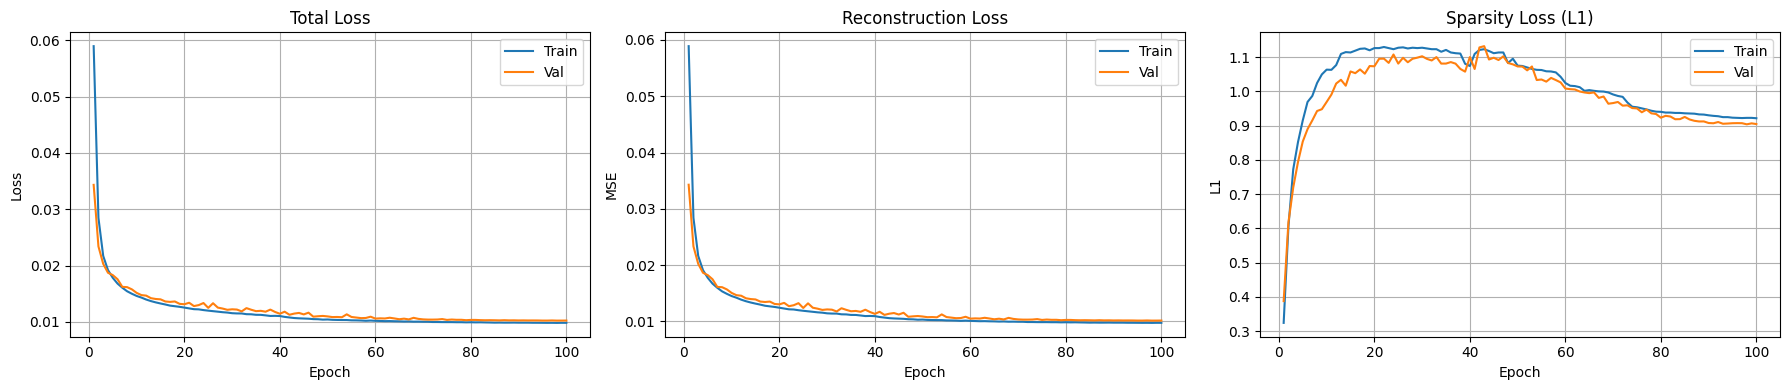

In [34]:
epochs_range = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Total loss
axes[0].plot(epochs_range, train_losses, label='Train')
axes[0].plot(epochs_range, val_losses, label='Val')
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Reconstruction loss
axes[1].plot(epochs_range, train_recon_losses, label='Train')
axes[1].plot(epochs_range, val_recon_losses, label='Val')
axes[1].set_title('Reconstruction Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE')
axes[1].legend()
axes[1].grid(True)

# Sparsity loss
axes[2].plot(epochs_range, train_sparsity_losses, label='Train')
axes[2].plot(epochs_range, val_sparsity_losses, label='Val')
axes[2].set_title('Sparsity Loss (L1)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('L1')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()


# 9. Reconstruction Quality

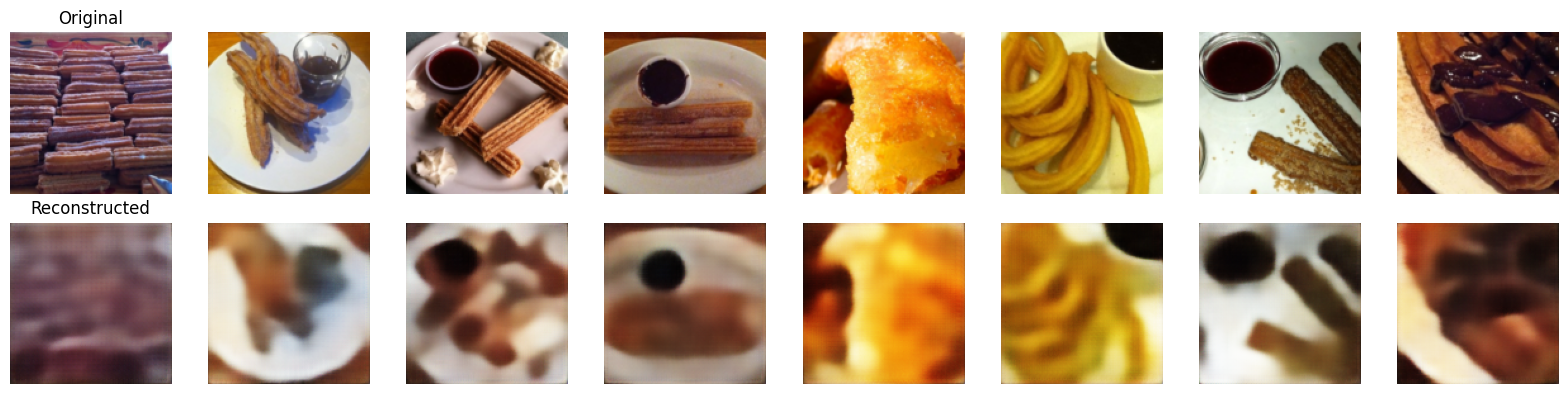

In [35]:
def visualize_reconstructions(model, loader, num_images=8):
    """
    Display original images alongside their reconstructions.

    Args:
        model:      Trained SAE model.
        loader:     DataLoader to sample images from.
        num_images: Number of image pairs to show.
    """
    model.eval()
    images, _ = next(iter(loader))
    images = images[:num_images].to(device)

    with torch.no_grad():
        reconstructed, _ = model(images)

    images = images.cpu()
    reconstructed = reconstructed.cpu()

    fig, axes = plt.subplots(2, num_images, figsize=(num_images * 2, 4))
    for i in range(num_images):
        # Original
        axes[0, i].imshow(images[i].permute(1, 2, 0).clamp(0, 1))
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title('Original')

        # Reconstructed
        axes[1, i].imshow(reconstructed[i].permute(1, 2, 0).clamp(0, 1))
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title('Reconstructed')

    plt.tight_layout()
    plt.show()


visualize_reconstructions(model, test_loader)


# 10. Sparsity Analysis

A well-trained SAE should exhibit high sparsity: only a small fraction of
latent units should be active (non-zero) for any given input.  We measure:

- **Mean activation per unit**: average absolute value across the test set.
- **Active-unit fraction**: percentage of units that fire for at least one
  test image (above a small threshold).
- **Per-image sparsity**: fraction of units that are zero for each image.


Analyzing Sparsity:   0%|          | 0/49 [00:13<?, ?it/s]

Active latent units (ever fired): 147 / 512 (28.7%)
Mean per-image sparsity (zero fraction): 0.713


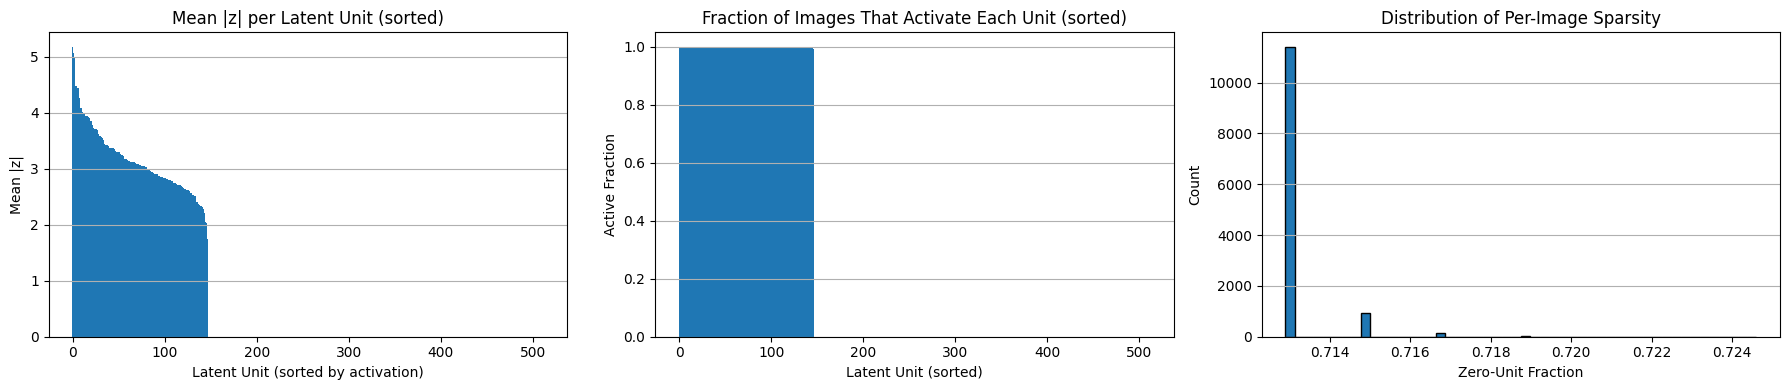

In [36]:
def analyze_sparsity(model, loader, latent_dim, threshold=1e-3):
    """
    Compute and visualize the sparsity of the latent code over the given loader.

    Args:
        model:      Trained SAE model.
        loader:     DataLoader to evaluate sparsity on.
        latent_dim: Number of latent dimensions.
        threshold:  Activation value below which a unit is considered 'off'.
    """
    model.eval()

    # Accumulate per-unit mean absolute activation and per-image sparsity
    sum_activations = torch.zeros(latent_dim)   # sum of |z| per unit
    sum_active_units = torch.zeros(latent_dim)  # counts images where unit > threshold
    total_images = 0
    per_image_sparsity = []  # fraction of zero units per image

    with torch.no_grad():
        for images, _ in tqdm(loader, desc="Analyzing Sparsity", leave=False):
            images = images.to(device)
            _, z = model(images)  # z shape: (B, latent_dim)
            z_cpu = z.cpu()

            sum_activations += z_cpu.abs().sum(dim=0)
            sum_active_units += (z_cpu.abs() > threshold).float().sum(dim=0)

            # Per-image: fraction of units that are zero
            zero_frac = (z_cpu.abs() <= threshold).float().mean(dim=1)  # (B,)
            per_image_sparsity.extend(zero_frac.tolist())

            total_images += images.size(0)

    mean_activation = sum_activations / total_images   # mean |z| per unit
    active_unit_frac = (sum_active_units / total_images).clamp(0, 1)

    # Units that fired in at least one image
    ever_active = (sum_active_units > 0).sum().item()
    print(f"Active latent units (ever fired): {ever_active} / {latent_dim} "
          f"({100.0 * ever_active / latent_dim:.1f}%)")
    print(f"Mean per-image sparsity (zero fraction): {np.mean(per_image_sparsity):.3f}")

    # Sort by activation magnitude for visualization
    sorted_activation, _ = mean_activation.sort(descending=True)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # Mean activation per unit (sorted)
    axes[0].bar(range(latent_dim), sorted_activation.numpy(), width=1.0)
    axes[0].set_title("Mean |z| per Latent Unit (sorted)")
    axes[0].set_xlabel("Latent Unit (sorted by activation)")
    axes[0].set_ylabel("Mean |z|")
    axes[0].grid(True, axis='y')

    # Active-unit fraction per unit (sorted)
    sorted_active, _ = active_unit_frac.sort(descending=True)
    axes[1].bar(range(latent_dim), sorted_active.numpy(), width=1.0)
    axes[1].set_title("Fraction of Images That Activate Each Unit (sorted)")
    axes[1].set_xlabel("Latent Unit (sorted)")
    axes[1].set_ylabel("Active Fraction")
    axes[1].grid(True, axis='y')

    # Distribution of per-image zero fractions
    axes[2].hist(per_image_sparsity, bins=50, edgecolor='black')
    axes[2].set_title("Distribution of Per-Image Sparsity")
    axes[2].set_xlabel("Zero-Unit Fraction")
    axes[2].set_ylabel("Count")
    axes[2].grid(True, axis='y')

    plt.tight_layout()
    plt.show()


analyze_sparsity(model, test_loader, LATENT_DIM)


# 11. Latent Space Interpolation

Because the SAE has a deterministic encoder (no sampling), we can directly
interpolate between the latent codes of two real images and decode the
intermediate representations.  A smooth interpolation indicates that the
learned latent space captures meaningful structure.


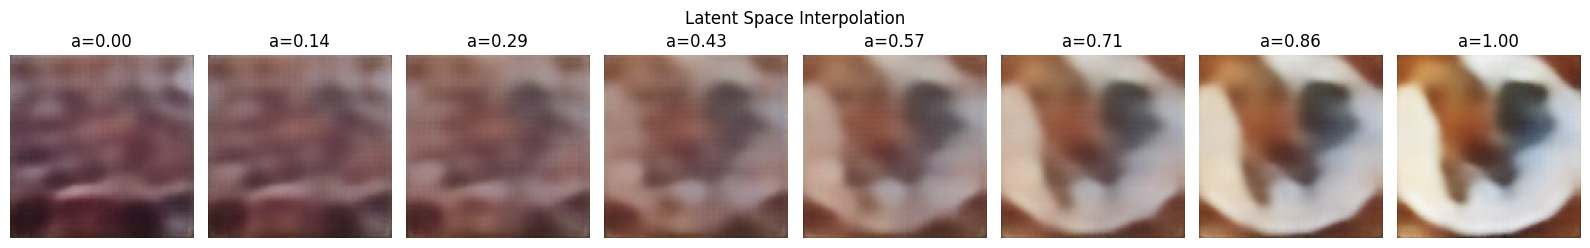

In [37]:
def interpolate_latents(model, loader, num_steps=8):
    """
    Linearly interpolate between the latent codes of two images.

    Args:
        model:     Trained SAE model.
        loader:    DataLoader to sample images from.
        num_steps: Number of interpolation steps (including endpoints).
    """
    model.eval()
    images, _ = next(iter(loader))
    img_a = images[0:1].to(device)  # first image
    img_b = images[1:2].to(device)  # second image

    with torch.no_grad():
        z_a = model.encode(img_a)  # (1, latent_dim)
        z_b = model.encode(img_b)  # (1, latent_dim)

    alphas = torch.linspace(0, 1, num_steps)

    fig, axes = plt.subplots(1, num_steps, figsize=(num_steps * 2, 2.5))
    for i, alpha in enumerate(alphas):
        z_interp = (1 - alpha) * z_a + alpha * z_b
        with torch.no_grad():
            img_interp = model.decode(z_interp).cpu().squeeze(0)
        axes[i].imshow(img_interp.permute(1, 2, 0).clamp(0, 1))
        axes[i].axis('off')
        axes[i].set_title(f'a={alpha:.2f}')

    plt.suptitle("Latent Space Interpolation")
    plt.tight_layout()
    plt.show()


interpolate_latents(model, test_loader)
